In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Function to plot the profit/loss of a strategy with profit and loss zones
def plot_strategy(S_range, payoff, title):
    # Plotting the payoff curve
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, payoff, label='Profit/Loss')
    
    # Plotting profit and loss zones
    plt.axhline(0, color='black', linestyle='--')  # Line at zero to separate profit/loss
    plt.fill_between(S_range, payoff, 0, where=(payoff >= 0), color='green', alpha=0.3, label='Profit Zone')
    plt.fill_between(S_range, payoff, 0, where=(payoff < 0), color='red', alpha=0.3, label='Loss Zone')
    
    # Adding title, labels, and grid
    plt.title(title)
    plt.xlabel("Underlying Price at Expiry (S)")
    plt.ylabel("Profit/Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

# Base parameters
K = 100       # Strike price
P = 10        # Option premium
S = np.linspace(50, 150, 500)  # Range of underlying prices at maturity

In [3]:
# Black-Scholes formula for European Call and Put
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Function to plot the option value
def plot_option_value(S_range, values, title):
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, values, label='Option Value', color='blue')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(title)
    plt.xlabel("Underlying Price $S$")
    plt.ylabel("Option Value (€)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Base parameters
r = 0.05        # Risk-free interest rate
sigma = 0.3     # Annual volatility
T_remaining = 0.25  # Time to maturity in years
S_range = np.linspace(50, 150, 500)

---

## BEARISH STRATEGIES → Betting on a price decrease

---

In [4]:
# 1. LONG PUT: 
# Buy a put: Right to sell the underlying asset at a fixed strike price.
# → Profits when the underlying falls below strike.
# Max loss = premium paid. Profit increases as price drops.
def long_put(K, P, S):
    return np.maximum(K - S, 0) - P

In [5]:
# 2. SHORT CALL: 
# Sell a call: Obligation to sell the asset if exercised.
# → Profitable when price stays below strike (call expires worthless).
# Max profit = premium received. Losses are unlimited if price rises.
def short_call(K, P, S):
    return np.minimum(K - S, 0) + P

In [6]:
# 3. BEAR CALL SPREAD:
# Sell a call at lower strike (K1), buy a call at higher strike (K2).
# Same underlying asset and expiration. 
# → Limited risk and limited reward.
# Profits if price stays below K1 (no call is exercised) → max profit = net premium. Losses if it goes above K2 (both calls exercised) → max loss = (K2 - K1) - net premium.
def bear_call_spread(K1, K2, P1, P2, S):
    return np.minimum(K1 - S, 0) + P1 + np.maximum(S - K2, 0) - P2

In [7]:
# 4. PUT SPREAD:
# Buy a put at higher strike (K2), sell a put at lower strike (K1).
# Same underlying asset and expiration. 
# → Limited risk and limited reward.
# Losses if price stays above K2 (both put expire worthless) → max loss = net premium paid. Profits if it goes under K1 (both puts exercised) → max profit = (K2 - K1) - net premium.

def put_spread(K1, K2, P1, P2, S):
    return np.maximum(K2 - S, 0) - P2 - (np.maximum(K1 - S, 0) - P1)

In [8]:
# 5. BEARISH RISK REVERSAL
# Buy a put, sell a call
# Gains and losses are generally uncapped
def bearish_risk_reversal(K_put, P_put, K_call, P_call, S):
    put_payoff = np.maximum(K_put - S, 0) - P_put
    call_payoff = np.minimum(K_call - S, 0) + P_call
    return put_payoff + call_payoff

---

## BULLISH STRATEGIES → Betting on a price increase

---

In [9]:
# 6. LONG CALL: 
# Buy a call: Right to buy the asset at strike price.
# → Profitable if the asset price rises above strike.
# Max loss = premium paid. Unlimited profit.
def long_call(K, P, S):
    return np.maximum(S - K, 0) - P

In [10]:
# 7. SHORT PUT: 
# Sell a put: Obligation to buy if price falls below strike.
# → Profits if the price stays above strike.
# Max gain = premium. Losses increase as price drops.
def short_put(K, P, S):
    return np.minimum(S - K, 0) + P

In [11]:
# 8. COVERED CALL: 
# Buy the underlying asset and sell a call option on it.
# If the stock price stays below the strike (S < K): The call expires worthless. You keep the premium and any gains or losses from the stock. Loss grows as S drops below S0.
# If the stock price exceeds the strike (S > K): The call is exercised — you must sell your stock at strike price. Total profit = (K - S0) + premium received.
def covered_call(K, P, S, S0):
    return (S - S0) + np.minimum(K - S, 0) + P

In [12]:
# 9. COLLAR: 
# Buy the stock + Buy a put option (for protection) + Sell a call option (to finance the put)
# → Limited risk and limited reward.
# If the stock price stays between the put strike (K_put) and the call strike (K_call): The put will provide protection from falling stock prices, and the call will not be exercised.
# If the stock price falls below the put strike (S < K_put): The put option protects you from further losses. → max loss = (S0 - K_put) - net premium received (from selling the call).
# If the stock price rises above the call strike (S > K_call): The call will be exercised, and you must sell your stock at the strike price (K_call). You  profit from the stock rise up to K_call and the call premium received. → max profit = (K_call - S0) + premium from the call option.

def collar(K_put, K_call, P_put, P_call, S, S0):
    put = np.maximum(K_put - S, 0) - P_put
    call = np.minimum(K_call - S, 0) + P_call
    stock = S - S0
    return stock + put + call

In [13]:
# 10. BULL CALL SPREAD:
# Buy call at lower strike (K1), sell call at higher strike (K2).
# Same underlying and expiration. 
# If the stock price stays below the lower strike price (S < K1): Both calls expire worthless. → max loss = net premium paid
# If the stock price is between the two strike prices (K1 < S < K2): The long call (bought at K1) will have value, but the short call (sold at K2) will be worthless. Your profit increases as the price rises toward K2.
# If the stock price exceeds the higher strike price (S > K2): Both calls will be exercised. For any price above K2, the maximum profit is achieved. → max profit = (K2 - K1) - Net Premium Paid

def bull_call_spread(K1, K2, P1, P2, S):
    return np.maximum(S - K1, 0) - P1 - (np.maximum(S - K2, 0) - P2)

In [14]:
# 11. BULLISH RISK REVERSAL
# Buy a call, sell a put
# Gains and losses are generally uncapped
def bullish_risk_reversal(K_call, P_call, K_put, P_put, S):
    call_payoff = np.maximum(S - K_call, 0) - P_call               # Long Call
    put_payoff = -np.maximum(K_put - S, 0) + P_put                 # Short Put
    return call_payoff + put_payoff

---

## NON-DIRECTIONAL STRATEGIES → Betting on volatility

---

In [15]:
# 12. LONG STRADDLE: 
# Buy a call and a put at the same strike.
# Betting on high volatility. If price moves significantly up/down → profit.
# If price stays at strike → max loss = sum of premiums
def long_straddle(K, P_call, P_put, S):
    return np.maximum(S - K, 0) + np.maximum(K - S, 0) - (P_call + P_put)

In [16]:
# 13. LONG STRANGLE: 
# Buy a put with lower strike and a call with higher strike.
# Cheaper than straddle. Needs very high volatility.
def long_strangle(K_put, K_call, P_put, P_call, S):
    return np.maximum(S - K_call, 0) + np.maximum(K_put - S, 0) - (P_put + P_call)

In [17]:
# 14. SHORT IRON CONDOR:
# Sell a Put at a higher strike (K_put_sell). Sell a Call at a lower strike (K_call_sell). Buy a Put at an even lower strike (K_put_buy). Buy a Call at an even higher strike (K_call_buy).
# Betting price stays in a range. 
# If the stock price stays between the two sold strikes (K_put_sell and K_call_sell), none of the options are exercised. The maximum profit is achieved, which is the premium received for selling the put and the call at the center, minus the premiums paid for the long options.
# If the stock price falls below the lower strike of the bought put (K_put_buy), both the sold put and the bought put will be exercised. The investor will gain the difference between the two put strikes (K_put_sell - K_put_buy), minus the net premium paid for the setup.
# If the stock price rises above the higher strike of the bought call (K_call_buy), both the sold call and the bought call will be exercised. The investor will gain the difference between the two call strikes (K_call_buy - K_call_sell), minus the net premium paid for setting up the position.
# If the stock price stays between the lower bought put strike (K_put_buy) and the higher bought call strike (K_call_buy), none of the bought options are exercised. The result will be the maximum loss equal to the net premium paid for the strategy.
def short_iron_condor(K_put_buy, K_put_sell, K_call_sell, K_call_buy, P_buy, P_sell, S):
    payoff = (
        (np.maximum(K_put_buy - S, 0) - P_buy) +  # Profit/Loss from the long put (K_put_buy)
        (np.minimum(S - K_put_sell, 0) + P_sell) +  # Profit/Loss from the sold put (K_put_sell)
        (np.minimum(K_call_sell - S, 0) + P_sell) +  # Profit/Loss from the sold call (K_call_sell)
        (np.maximum(S - K_call_buy, 0) - P_buy)  # Profit/Loss from the long call (K_call_buy)
    )
    return payoff

---

## PLOT EXAMPLES

---

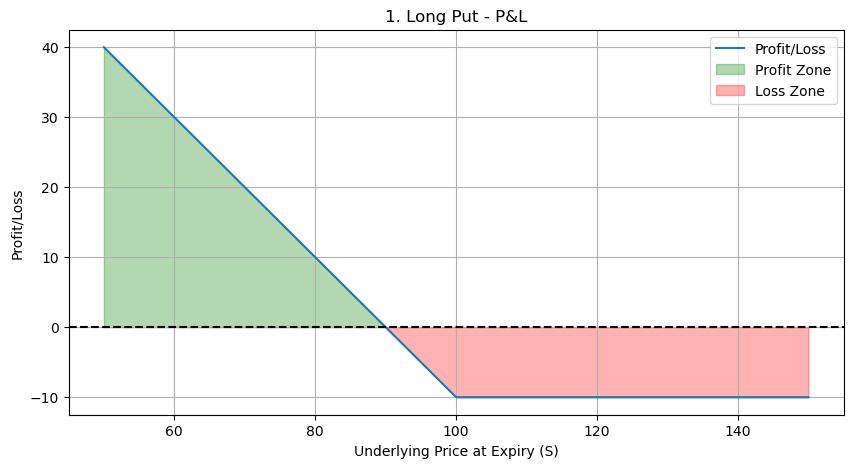

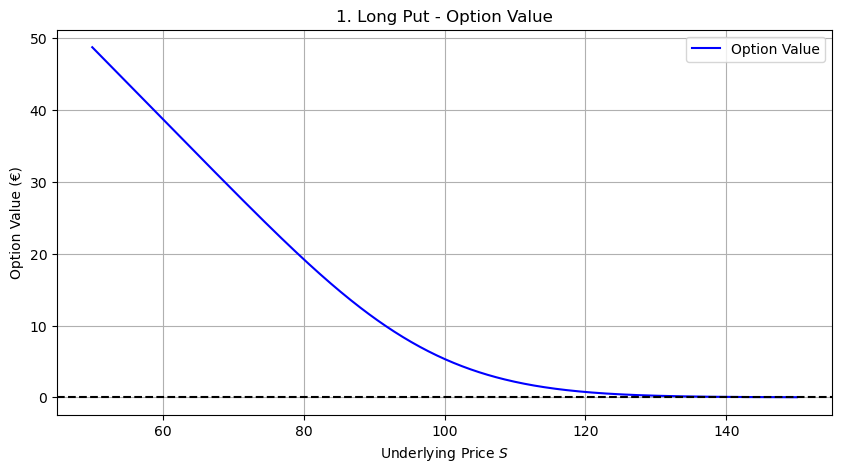

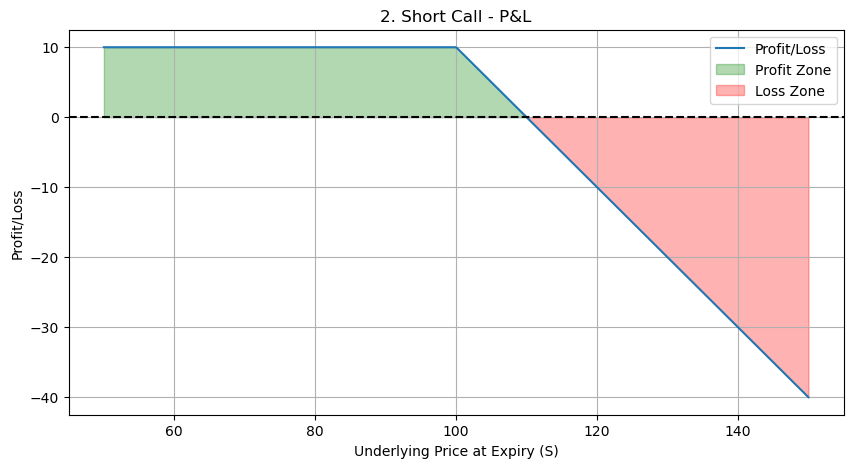

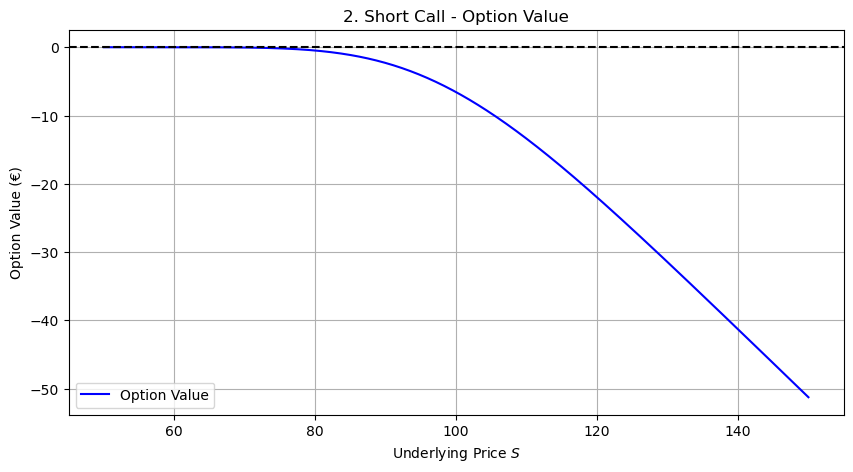

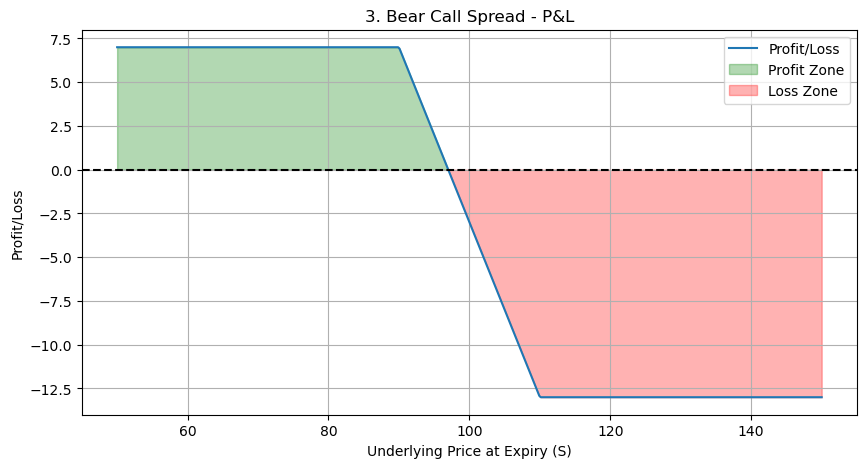

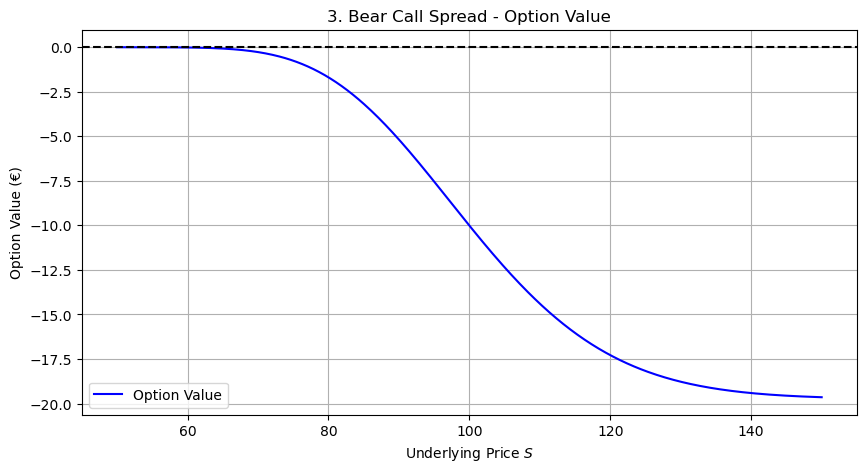

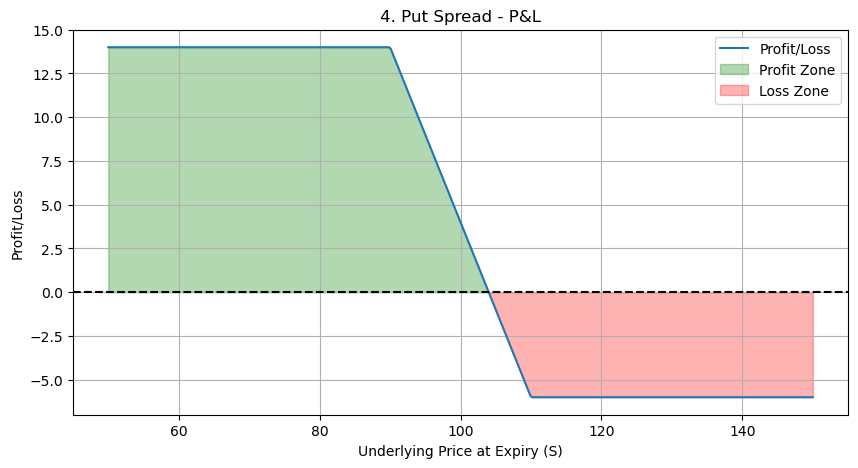

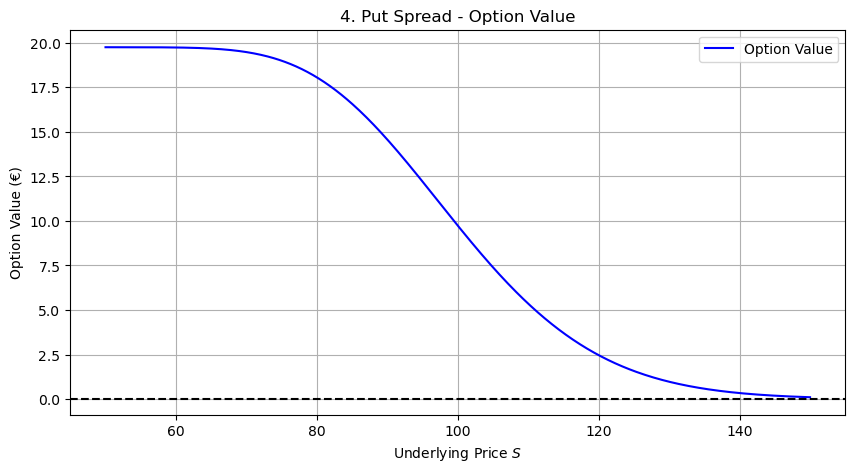

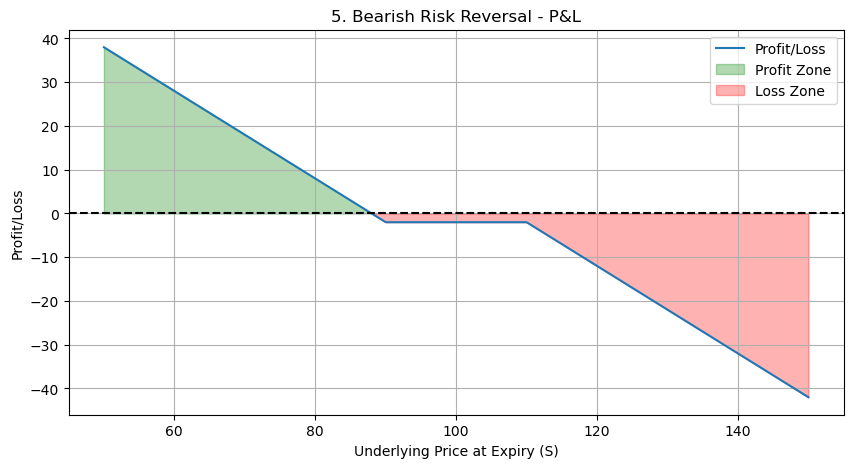

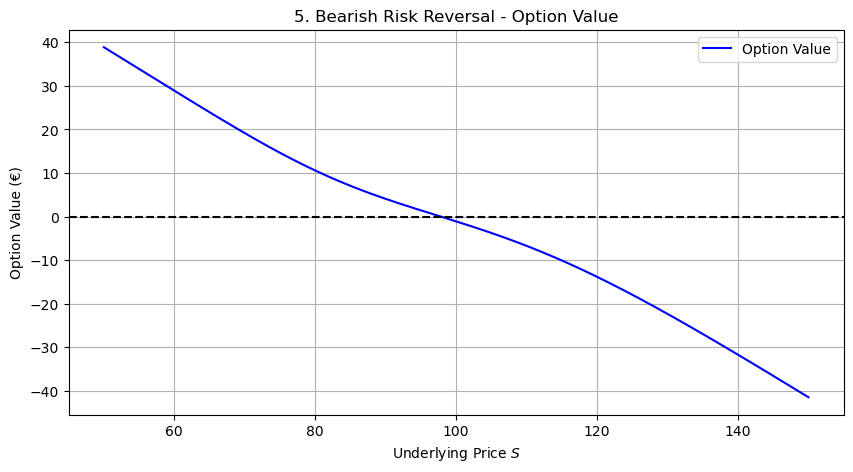

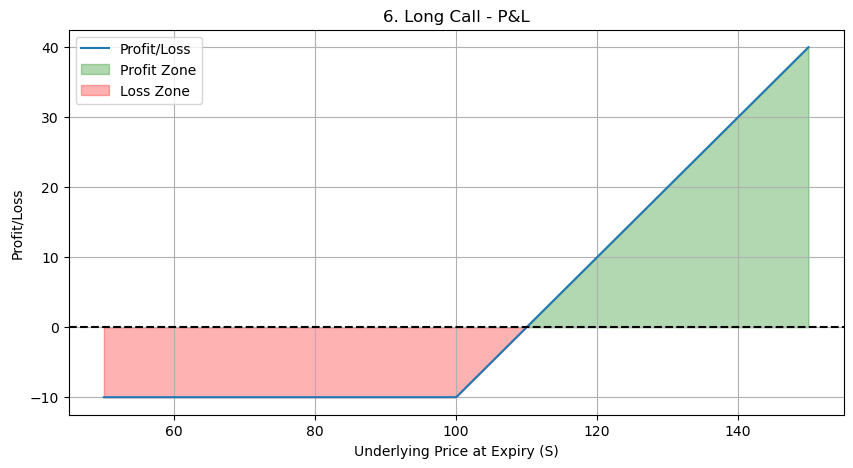

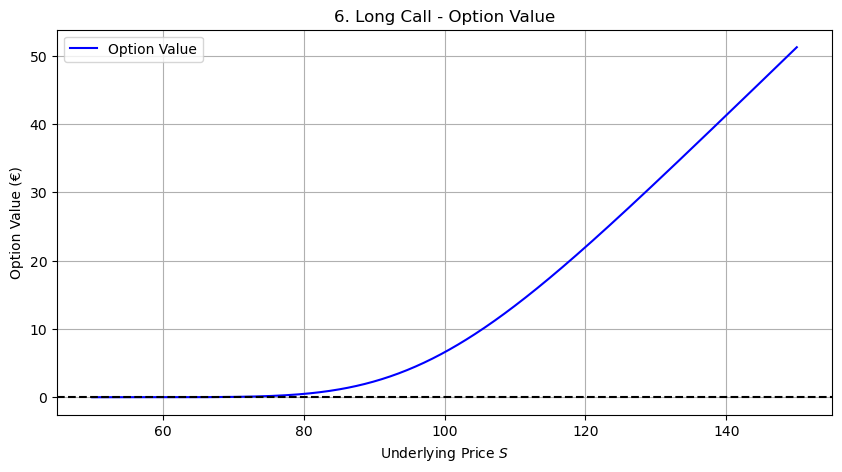

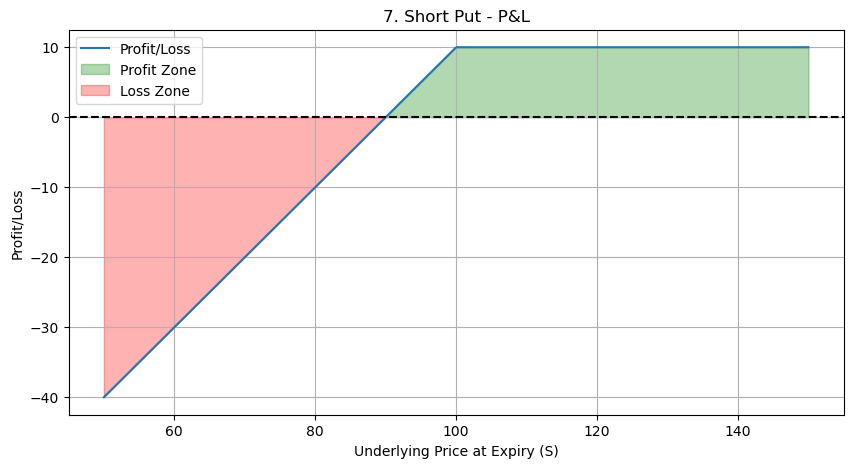

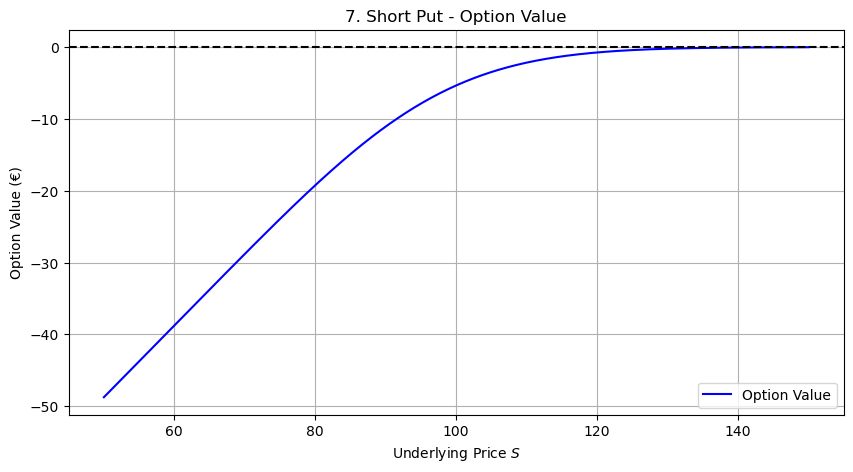

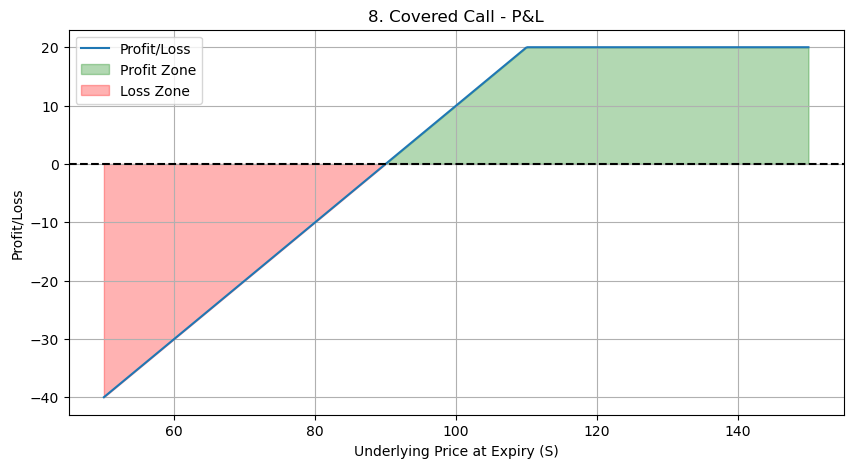

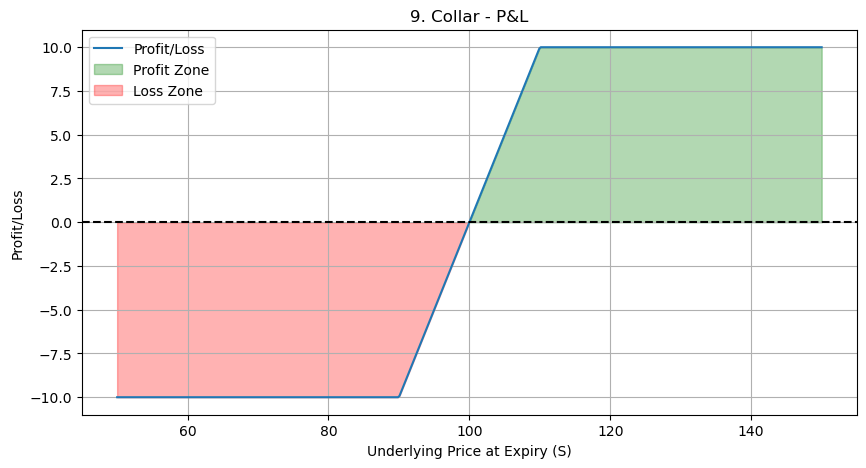

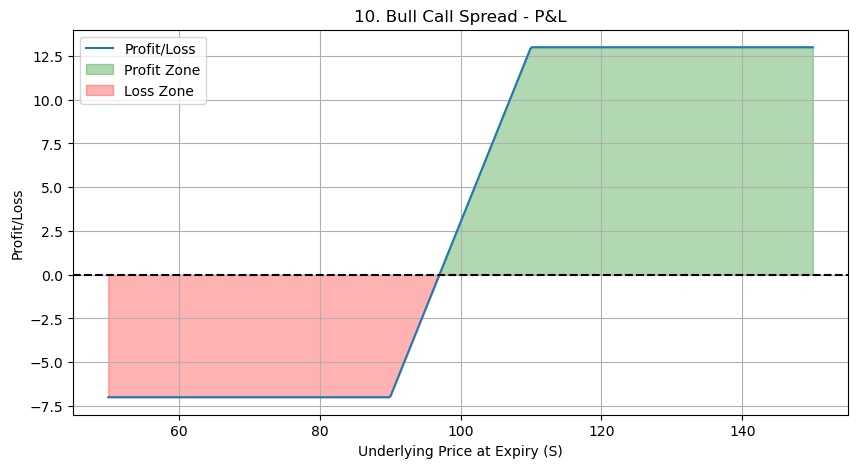

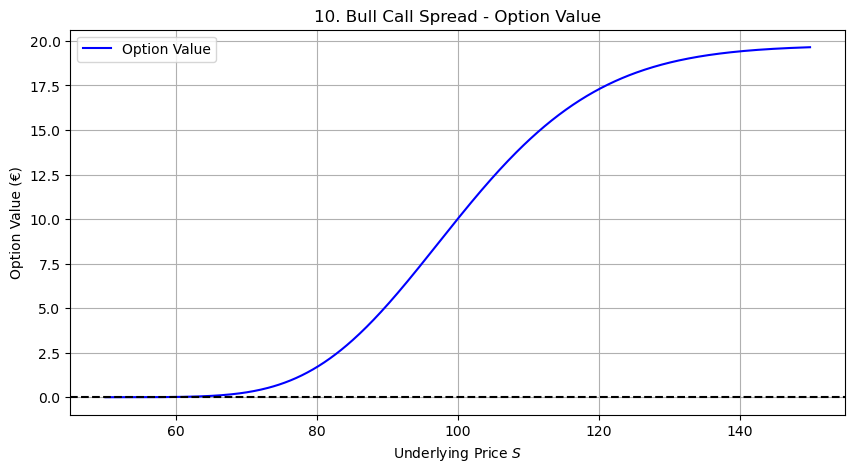

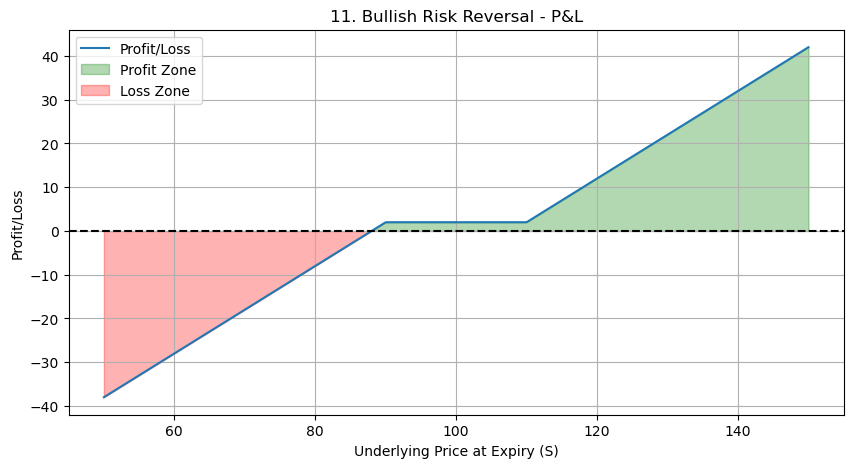

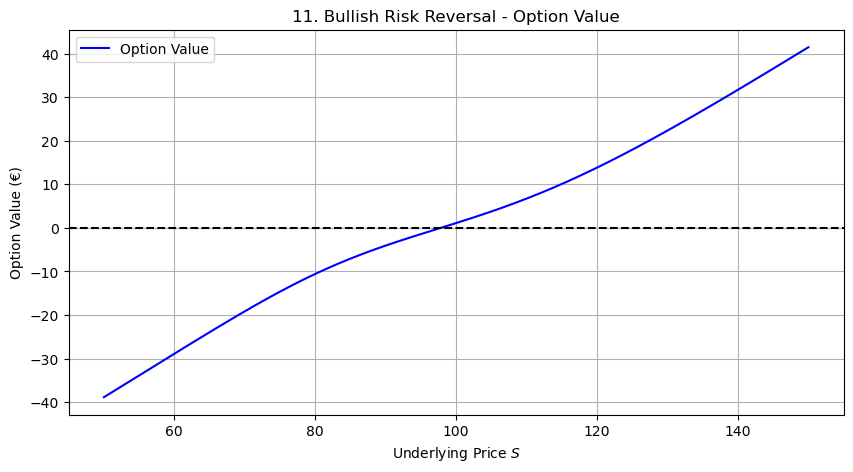

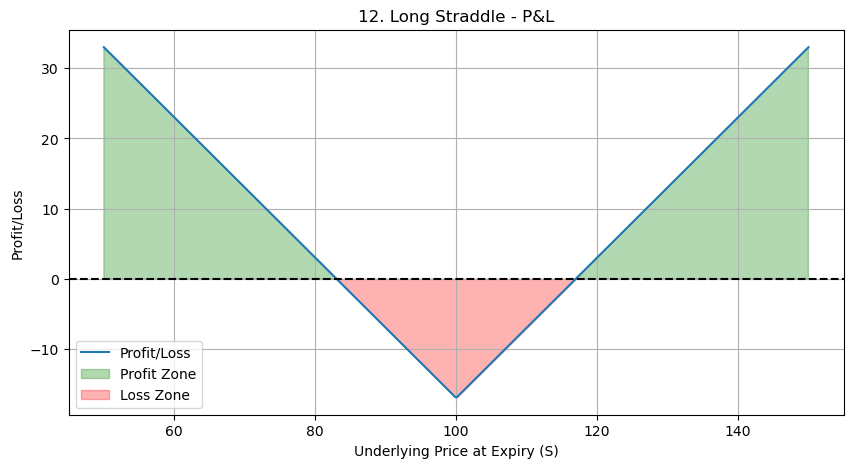

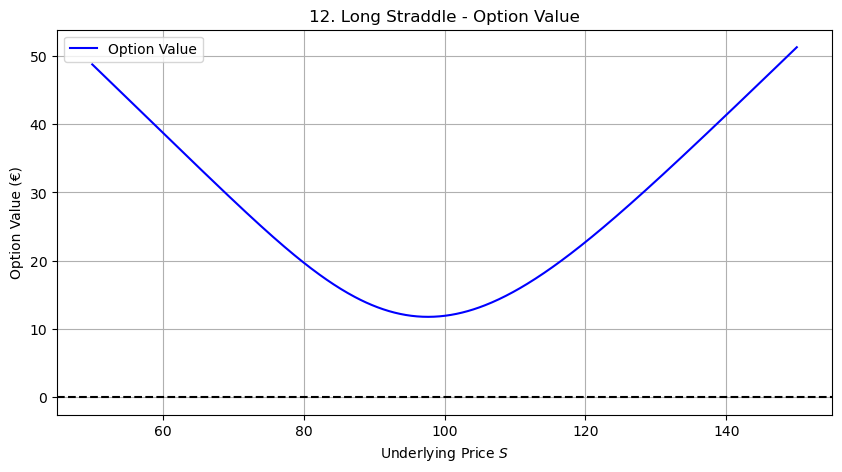

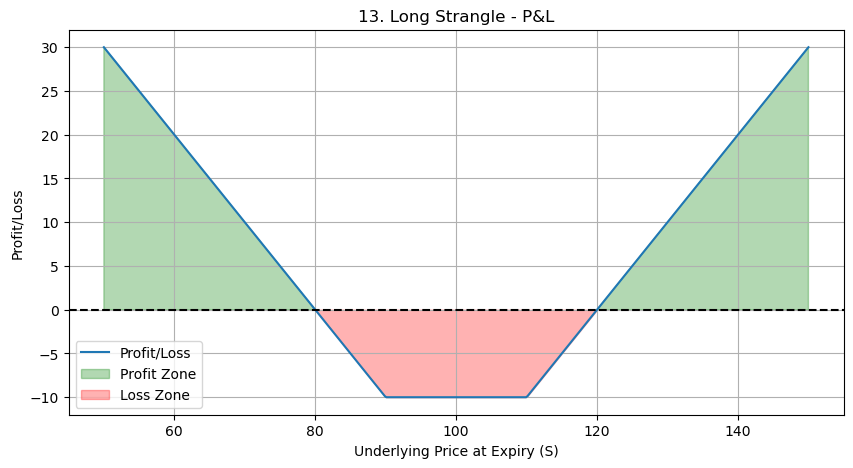

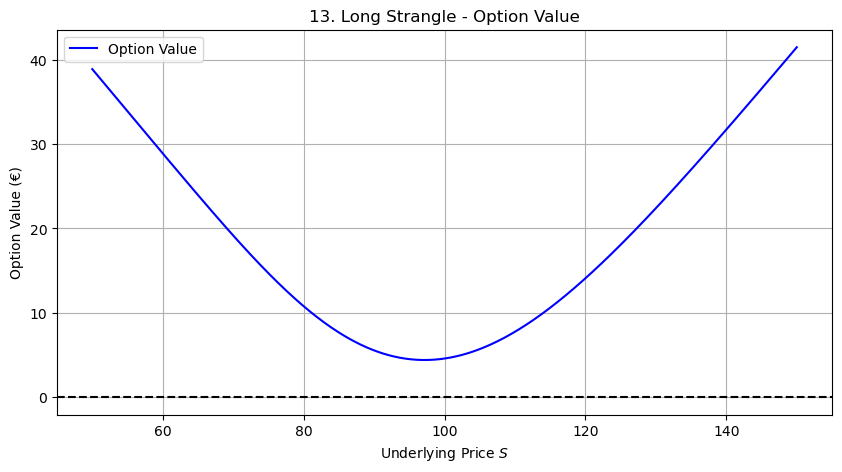

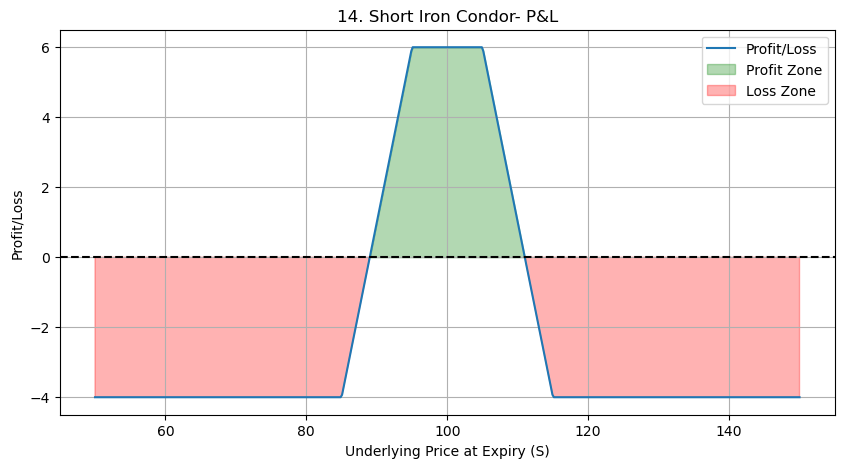

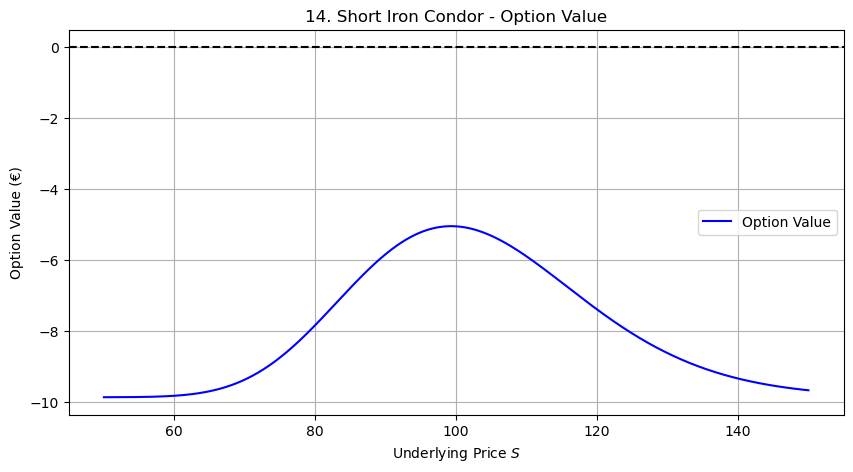

In [18]:
plot_strategy(S, long_put(K, P, S), "1. Long Put - P&L")
put_values = [black_scholes_put(S, K, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, put_values, "1. Long Put - Option Value")

plot_strategy(S, short_call(K, P, S), "2. Short Call - P&L")
call_values = [-black_scholes_call(S, K, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, call_values, "2. Short Call - Option Value")

plot_strategy(S, bear_call_spread(90, 110, 12, 5, S), "3. Bear Call Spread - P&L")
bear_call_values = [-black_scholes_call(S, 90, T_remaining, r, sigma) + black_scholes_call(S, 110, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, bear_call_values, "3. Bear Call Spread - Option Value")

plot_strategy(S, put_spread(90, 110, 4, 10, S), "4. Put Spread - P&L")
put_spread_values = [black_scholes_put(S, 110, T_remaining, r, sigma) - black_scholes_put(S, 90, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, put_spread_values, "4. Put Spread - Option Value")

plot_strategy(S, bearish_risk_reversal(90, 6, 110, 4, S), "5. Bearish Risk Reversal - P&L")
bearish_rr_values = [black_scholes_put(s, 90, T_remaining, r, sigma) - black_scholes_call(s, 110, T_remaining, r, sigma) for s in S_range]
plot_option_value(S_range, bearish_rr_values, "5. Bearish Risk Reversal - Option Value")

plot_strategy(S, long_call(K, P, S), "6. Long Call - P&L")
call_values = [black_scholes_call(S, K, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, call_values, "6. Long Call - Option Value")

plot_strategy(S, short_put(K, P, S), "7. Short Put - P&L")
put_values = [-black_scholes_put(S, K, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, put_values, "7. Short Put - Option Value")

plot_strategy(S, covered_call(110, 5, S, 95), "8. Covered Call - P&L")

plot_strategy(S, collar(90, 110, 5, 5, S, 100), "9. Collar - P&L")

plot_strategy(S, bull_call_spread(90, 110, 10, 3, S), "10. Bull Call Spread - P&L")
bull_call_values = [black_scholes_call(S, 90, T_remaining, r, sigma) - black_scholes_call(S, 110, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, bull_call_values, "10. Bull Call Spread - Option Value")

plot_strategy(S, bullish_risk_reversal(110, 5, 90, 7, S), "11. Bullish Risk Reversal - P&L")
bullish_rr_values = [black_scholes_call(s, 110, T_remaining, r, sigma) - black_scholes_put(s, 90, T_remaining, r, sigma) for s in S_range]
plot_option_value(S_range, bullish_rr_values, "11. Bullish Risk Reversal - Option Value")

plot_strategy(S, long_straddle(100, 8, 9, S), "12. Long Straddle - P&L")
straddle_values = [black_scholes_call(S, 100, T_remaining, r, sigma) + black_scholes_put(S, 100, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, straddle_values, "12. Long Straddle - Option Value")

plot_strategy(S, long_strangle(90, 110, 5, 5, S), "13. Long Strangle - P&L")
strangle_values = [black_scholes_put(S, 90, T_remaining, r, sigma) + black_scholes_call(S, 110, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, strangle_values, "13. Long Strangle - Option Value")

plot_strategy(S, short_iron_condor(85, 95, 105, 115, 4, 7, S), "14. Short Iron Condor- P&L")
iron_condor_values = [-black_scholes_put(S, 95, T_remaining, r, sigma) + black_scholes_put(S, 85, T_remaining, r, sigma)-black_scholes_call(S, 105, T_remaining, r, sigma) + black_scholes_call(S, 115, T_remaining, r, sigma) for S in S_range]
plot_option_value(S_range, iron_condor_values, "14. Short Iron Condor - Option Value")